 46.4%  232 of  500 [##################----------------------] 07:00:53

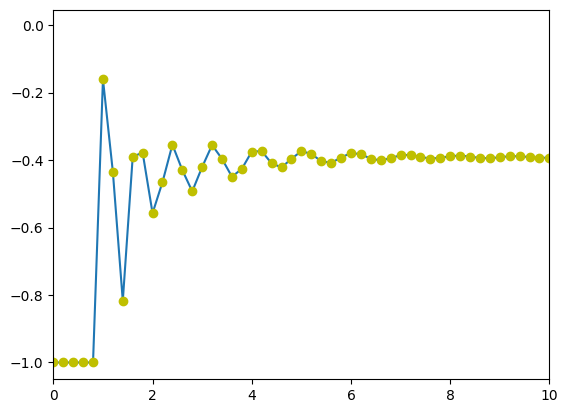

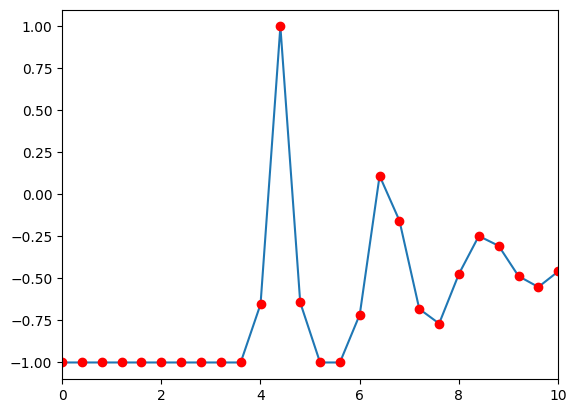

0.030097495752241684


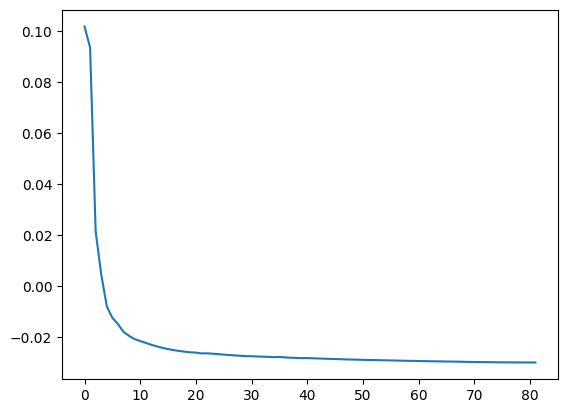

0.027658271554079072


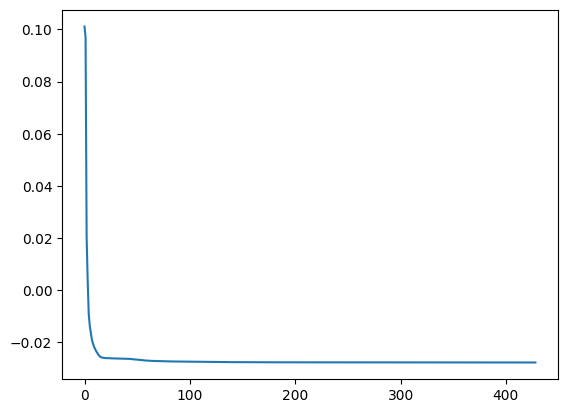

 50.0%   50 of  100 [####################--------------------] 08:14:50

In [ ]:
import dill
import matplotlib.pyplot as plt
import numpy as np


with open('results/zero_control/conv_checks/dt=0.2_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/2000ps', 'rb') as f:
    opt_dict_1K_1 = dill.load(f)

with open('results/zero_control/conv_checks/dt=0.1_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/500ps', 'rb') as f:
    opt_dict_1K_1_finer = dill.load(f)

with open('results/processtensors/processtensor_dt=0.2_ps=-8.0_tcut=500', 'rb') as f:
    pt_1K_1 = dill.load(f)

with open('results/processtensors/processtensor_dt=0.1_ps=-8.0_tcut=500', 'rb') as f:
    pt_1K_1_finer = dill.load(f)

with open('results/processtensors/processtensorcf_dt=0.2_ps=-8.0_tcut=500', 'rb') as f:
    pt_1K_1_cf = dill.load(f)

with open('results/processtensors/processtensorcf_dt=0.1_ps=-8.0_tcut=500', 'rb') as f:
    pt_1K_1_cf_finer = dill.load(f)

num_it=-1

hx_tempo=opt_dict_1K_1['log'][num_it]['x'][:,0::3][0::2].flatten()
hx_tempo_finer=opt_dict_1K_1_finer['log'][num_it]['x'][:,0::3][0::2].flatten()
heat_tempo=opt_dict_1K_1['log'][num_it]['full heats']


plt.plot(np.linspace(0,2000,len(hx_tempo)),hx_tempo)
plt.plot(np.linspace(0,2000,len(hx_tempo)),hx_tempo,'yo')
plt.xlim(0,50*0.2)
plt.show()
plt.plot(np.linspace(0,2000,len(hx_tempo_finer)),hx_tempo_finer)
plt.plot(np.linspace(0,2000,len(hx_tempo_finer)),hx_tempo_finer,'ro')
plt.xlim(0,100*0.1)
plt.show()

num_its=np.shape(opt_dict_1K_1['log'])[-1]
fin_heats=[entry['full heats'][-1] for entry in opt_dict_1K_1['log']]
print(max(-1*np.array(fin_heats)))
plt.plot(range(num_its),fin_heats)
plt.show()

num_its=np.shape(opt_dict_1K_1_finer['log'])[-1]
fin_heats=[entry['full heats'][-1] for entry in opt_dict_1K_1_finer['log']]
print(max(-1*np.array(fin_heats)))
plt.plot(range(num_its),fin_heats)
plt.show()


In [ ]:
f_time=100
num_steps=int(100/0.2)
hx_linear=-np.ones(num_steps)*2
hx_linear[0:10]=-2

#hx_tempo_early=opt_dict_lindblad[(0.1,1)]["hx_opt"]

control_times = np.linspace(0, f_time, len(hx_linear), endpoint=True)

h_t = interp1d(control_times, hx_linear, kind='previous', fill_value="extrapolate")

plt.plot(control_times,hx_linear,'bo')
plt.plot(control_times,h_t(control_times))
plt.show()

sys= TimeDependentSystem(lambda t : op.sigma("x")*h_t(t))
heat_ramp_tempo=oqupy.compute_dynamics(sys,rho0,pt_1K_1_cf.dt,num_steps,0,pt_1K_1_cf).states.trace(axis1=1,axis2=2).imag/0.01

num_steps_finer=int(100/0.1)
hx_linear=-np.ones(num_steps_finer)*2
hx_linear[0:10]=-2

#hx_tempo_early=opt_dict_lindblad[(0.1,1)]["hx_opt"]

control_times = np.linspace(0, f_time, len(hx_linear), endpoint=True)

h_t = interp1d(control_times, hx_linear, kind='previous', fill_value="extrapolate")

plt.plot(control_times,hx_linear,'bo')
plt.plot(control_times,h_t(control_times))
plt.show()
sys= TimeDependentSystem(lambda t : op.sigma("x")*h_t(t))
heat_ramp_tempo_finer=oqupy.compute_dynamics(sys,rho0,pt_1K_1_cf_finer.dt,num_steps_finer,0,pt_1K_1_cf_finer).states.trace(axis1=1,axis2=2).imag/0.01

501
1001


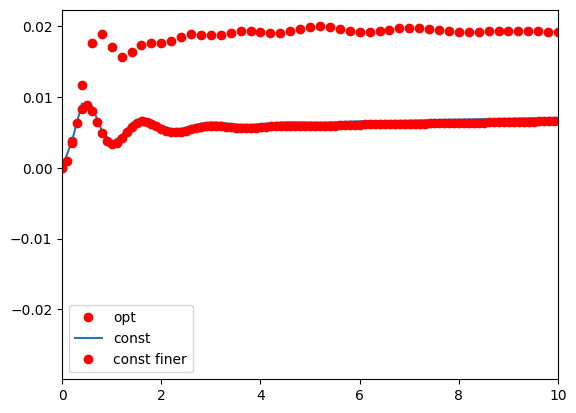

 70.0%   70 of  100 [############################------------] 05:38:19

In [ ]:
plt.plot(np.linspace(0,2000,len(heat_tempo)),heat_tempo,'ro',label='opt')
print(len(heat_ramp_tempo))
print(len(heat_ramp_tempo_finer))
plt.plot(np.linspace(0,100,len(heat_ramp_tempo)-1),heat_ramp_tempo[:num_steps],label='const')
plt.plot(np.linspace(0,100,len(heat_ramp_tempo_finer)-1),heat_ramp_tempo_finer[:num_steps_finer],'ro',label='const finer')
plt.xlim(0,10)
plt.legend()
plt.show()

dict_keys([(0.05, 1), (0.1, 1), (0.05, 10), (0.1, 10)])
0.33499999999999996
 70.0%   70 of  100 [############################------------] 08:17:53

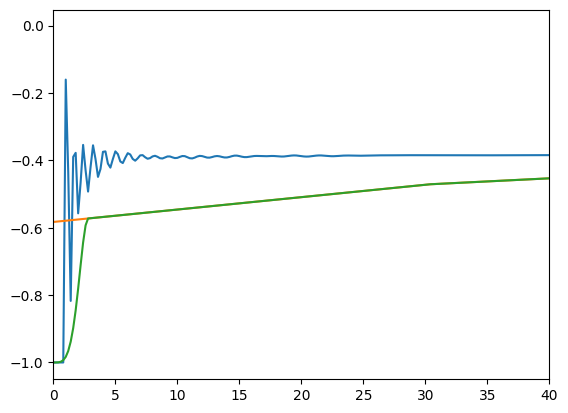

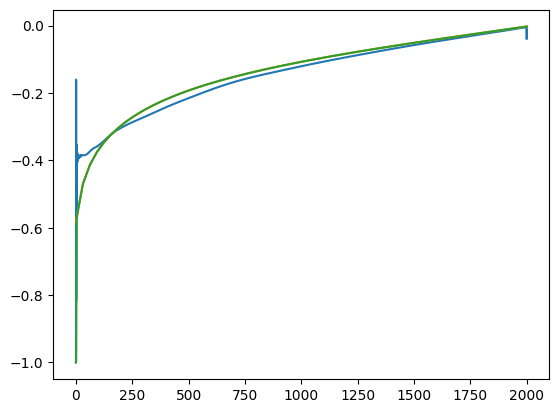

 70.0%   70 of  100 [############################------------] 08:19:07

In [ ]:
import dill

with open('paper_data/opt_dict_lindblad', 'rb') as f:
    opt_dict_lindblad = dill.load(f)

print(opt_dict_lindblad.keys())


hx_lindblad=opt_dict_lindblad[(0.1,1)]["hx_opt"]

#hx_lindblad=opt_dict_lindblad[(0.1,1)]["hx_opt"]
print(10/(2000/len(hx_lindblad)))

control_times = np.linspace(0, 2000, len(hx_lindblad), endpoint=True)

h_t = interp1d(control_times, hx_lindblad, kind='linear', fill_value="extrapolate")

hx_lindblad_tempogrid=h_t(np.linspace(0,2000,10000))
plt.plot(np.linspace(0,2000,len(hx_tempo)),hx_tempo)
plt.plot(np.linspace(0,2000,10000),hx_lindblad_tempogrid)
#plt.plot(np.linspace(0,2000,len(hx_lindblad)),hx_lindblad)

def smoothstep(n):
    x = np.linspace(0, 1, n)
    gamma=2
    x = x**gamma
    return 0.5 * (1 - np.cos(np.pi * x))

hx_smoothed = hx_lindblad_tempogrid.copy()
n_ramp=15

w = smoothstep(n_ramp)

hx_smoothed[:n_ramp] = (1 - w) * (-1.0) + w * hx_lindblad_tempogrid[:n_ramp]
plt.plot(np.linspace(0,2000,len(hx_smoothed)),hx_smoothed)


plt.xlim(0,40)
plt.show()
plt.plot(np.linspace(0,2000,len(hx_tempo)),hx_tempo)
plt.plot(np.linspace(0,2000,10000),hx_lindblad_tempogrid)
#plt.plot(np.linspace(0,2000,len(hx_lindblad)),hx_lindblad)

plt.plot(np.linspace(0,2000,len(hx_smoothed)),hx_smoothed)



In [ ]:
import oqupy
from oqupy import operators as op
from oqupy.system import ParameterizedSystem2ls
control_labels=["tempo opt","lindblad opt","smoothed"]
def ham_param(hx,hy,hz):
    return hx*op.sigma("x")+hy*op.sigma("y")+hz*op.sigma("z")

Rho_0=op.spin_dm("x+")

result_dict={control_labels[0]:{},control_labels[1]:{},control_labels[2]:{}}

system=ParameterizedSystem2ls(ham_param)
u=0.01
num_params=3
num_steps=int(2000/pt_1K_1_cf.dt)

for i,control_parameters in enumerate([hx_tempo,hx_lindblad_tempogrid,hx_smoothed]):
    print(control_labels[i])
    input_controls=[1e-6]*num_steps*num_params
    input_controls[::3]=control_parameters
    input_controls=np.array(input_controls)
    input_controls = [i for i in (input_controls.reshape((-1,num_params))).tolist() for j in range(2)]
    input_controls=np.array(input_controls)

    grad_dict = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=op.spin_dm('mixed').T,
        process_tensors=[pt_1K_1_cf],
        num_steps=num_steps,
        parameters=input_controls,
        progress_type='silent')
    
    fs_times=grad_dict['dynamics']

    heat_times=fs_times.states.trace(axis1=1,axis2=2).imag/u
    
    result_dict[control_labels[i]]["heat"]=heat_times
    

tempo opt
 46.4%  232 of  500 [##################----------------------] 06:53:53lindblad opt
 70.0%   70 of  100 [############################------------] 08:05:21smoothed
 28.6%  286 of 1000 [###########-----------------------------] 06:51:50

 70.0%   70 of  100 [############################------------] 08:07:01

-0.030097495742987722
-0.016825247425295724
-0.024067964772070963
 50.0%   50 of  100 [####################--------------------] 3 days, 21:31:11

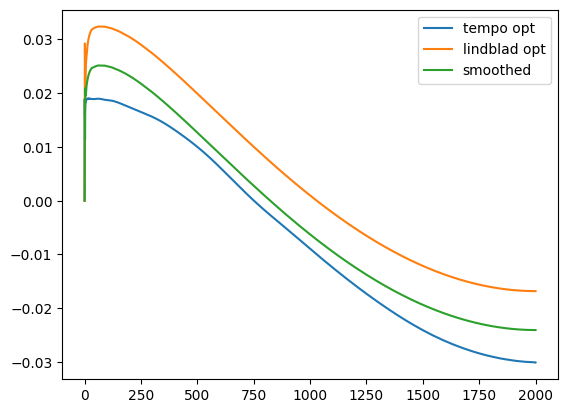

 50.0%   50 of  100 [####################--------------------] 3 days, 21:31:12

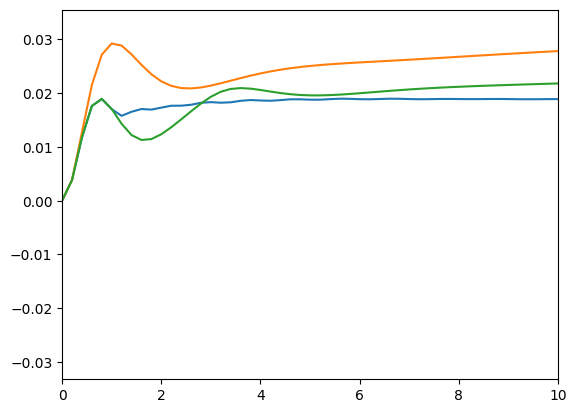

 70.0%   70 of  100 [############################------------] 6 days, 8:01:479

In [ ]:
for key in result_dict:
    plt.plot(np.linspace(0,2000,num_steps+1),result_dict[key]["heat"],label=key)
    print(result_dict[key]["heat"][-1])
plt.legend()
plt.show()
for key in result_dict:
    plt.plot(np.linspace(0,2000,num_steps+1),result_dict[key]["heat"])
    plt.xlim(0,10)
plt.show()

In [213]:
result_dict_const={"const 0.4":[],"const 1":[],"osc+const":[]}
const_labels=["const 0.4","const 1","osc+const"]

const_control_4=hx_tempo[int(20//pt_1K_1_cf.dt)]*np.ones(num_steps)
const_control_1=-np.ones(num_steps)

osc_control=const_control_4.copy()
osc_control[:int(20//pt_1K_1_cf.dt)]=hx_tempo[:int(20//pt_1K_1_cf.dt)]

for i,control_parameters in enumerate([const_control_4,const_control_1,osc_control]):

    print(control_labels[i])
    input_controls=[1e-6]*num_steps*num_params
    input_controls[::3]=control_parameters
    input_controls=np.array(input_controls)
    input_controls = [i for i in (input_controls.reshape((-1,num_params))).tolist() for j in range(2)]
    input_controls=np.array(input_controls)

    grad_dict = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=op.spin_dm('mixed').T,
        process_tensors=[pt_1K_1_cf],
        num_steps=500,
        parameters=input_controls,
        progress_type='silent')
    
    fs_times=grad_dict['dynamics']

    heat_times=fs_times.states.trace(axis1=1,axis2=2).imag/u
    
    result_dict_const[const_labels[i]]=heat_times

tempo opt
 50.0%   50 of  100 [####################--------------------] 08:28:27

 50.0%   50 of  100 [####################--------------------] 08:28:30lindblad opt
 70.0%   70 of  100 [############################------------] 08:28:52smoothed
 70.0%   70 of  100 [############################------------] 08:28:55

 70.0%   70 of  100 [############################------------] 08:28:56

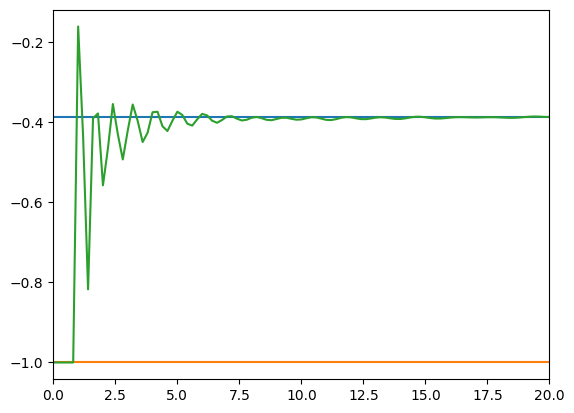

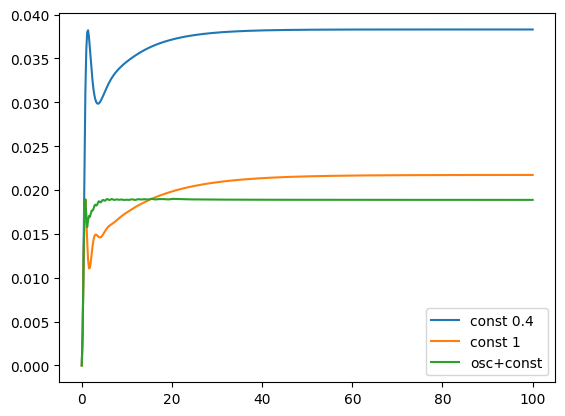

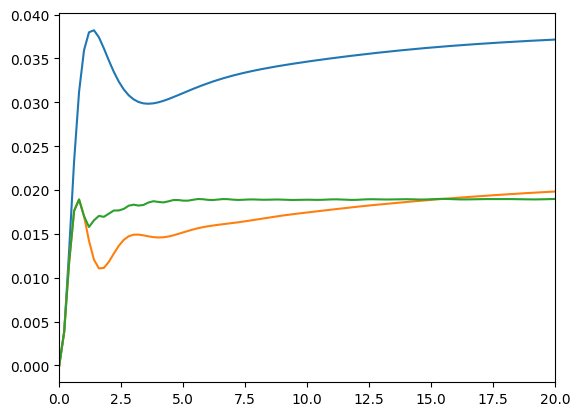

 50.0%   50 of  100 [####################--------------------] 3 days, 21:30:58

In [ ]:
for control in [const_control_4,const_control_1,osc_control]:
    plt.plot(np.linspace(0,2000,num_steps),control)
plt.xlim(0,20)
plt.show()
for key in result_dict_const:
    plt.plot(np.linspace(0,500*0.2,500+1),result_dict_const[key],label=key)

plt.legend()
plt.show()
for key in result_dict_const:
    plt.plot(np.linspace(0,500*0.2,500+1),result_dict_const[key])
    plt.xlim(0,20)
plt.show()

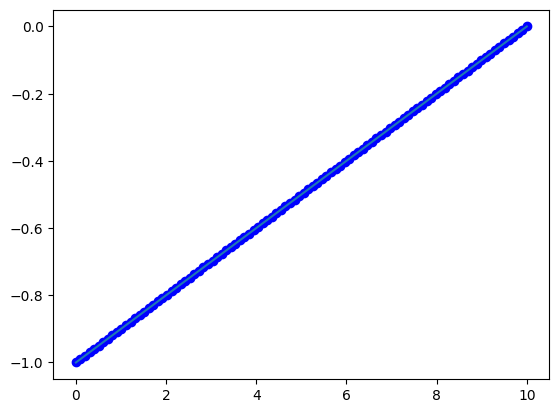

--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:36
Elapsed time: 36.7s
 70.0%   70 of  100 [############################------------] 04:01:09

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


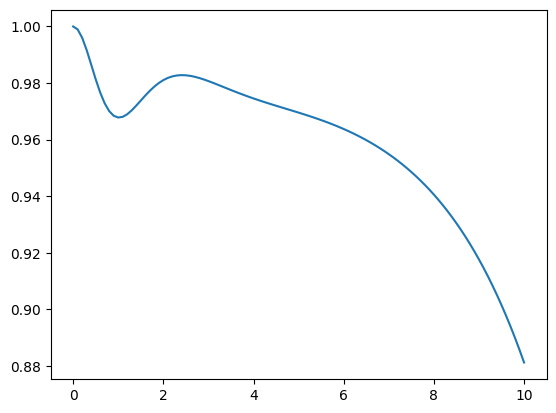

 28.6%  286 of 1000 [###########-----------------------------] 02:46:26

In [ ]:
import oqupy
from scipy.interpolate import interp1d
from oqupy import TimeDependentSystem, ParakmeterizedSystem2ls

pt=pt_1K_1_finer
rho0 = op.spin_dm("x+") 
omega_c=1


f_time=10
num_steps=int(f_time/pt.dt)

hx_tempo_early=hx_tempo[:num_steps]
hx_linear=np.linspace(-1,0,num_steps)
#hx_tempo_early=opt_dict_lindblad[(0.1,1)]["hx_opt"]

control_times = np.linspace(0, f_time, len(hx_tempo_early), endpoint=True)

h_t = interp1d(control_times, hx_linear, kind='previous', fill_value="extrapolate")

plt.plot(control_times,hx_linear,'bo')
plt.plot(control_times,h_t(control_times))
plt.show()

sys= TimeDependentSystem2ls(lambda t : op.sigma("x")*h_t(t))

t,sx_t=oqupy.compute_dynamics(sys,rho0,pt.dt,num_steps,0,pt).expectations(op.sigma("x"))

plt.plot(t,sx_t)
#plt.plot(t,sx_tempo[:num_steps+1],'ro')
plt.show()
corr = oqupy.PowerLawSD(0.1, 1, omega_c, temperature = 0.131,cutoff_type='exponential')
bath = oqupy.Bath(op.sigma("z")/2, corr)
bath_corr = oqupy.bath_dynamics.TwoTimeBathCorrelations(sys, bath, pt, rho0)

In [ ]:
# change in delta n (w,t) for early time

omega_c=1
pt.length=num_steps
heat_list = []
heat_list_t=[]
omega_list=np.linspace(0,3*omega_c,100)
pt_1K_1.length=num_steps

for w in omega_list:
    tlist, occ = bath_corr.occupation(w, 5*omega_c/100, True)
    heat_list.append(w * occ[-1])
    heat_list_t.append(w*occ.real)
plt.plot(omega_list, heat_list)

plt.xlabel(r"Mode Frequency$/\Omega$")
plt.ylabel(r"Heat Exchanged$/\Omega$")

T_grid, W_grid = np.meshgrid(tlist, omega_list)
plt.pcolormesh(T_grid, W_grid, heat_list_t, shading='auto')

--> Compute correlations:
  0.0%    0 of  100 [----------------------------------------] 00:00:16
Elapsed time: 16.9s


KeyboardInterrupt: 

In [12]:
def w(theta):
    if np.abs(theta)<0.1:
        return 1.0-theta**2/12+theta**4/360-theta**6/20160
    else:
        return 2*(1-np.cos(theta))/(theta**2)
    
def alpha0(theta):
    if np.abs(theta)<0.1:
        return -0.5+theta**2/24-theta**4/720+theta**6/40320 + \
            1.0j*theta*(1.0/6.0-theta**2/120+theta**4/5040-theta**6/362880)
    else:
        return -(1-np.cos(theta))/(theta**2)+1.0j*(theta-np.sin(theta))/theta**2

def trapezoidal_fft_integral(samples,a,delta,n):
    r'''
    Numerically computes the Fourier integral $\int_a^b e^{i\omega t} f(t)$, using the FFT with endpoint corrections.
    Function f(t) is given as the array samples, where samples[k] is the value of the function at the time $a+k*\delta$.
    $a$ is the lower limit of integral
    $\Delta$ is the time spacing.
    n is the number of points at which to compute the Fourier transform, which is adjusted to an even number.
    It should be chosen so as to oversample the function f(t) by a sufficient factor. 
    Note that the upper limit $b=a+m\Delta$, where m=samples.shape[0]-1, i.e. the maximum time in the array.
    Returns omegas,dftres, where omegas are the angular frequencies at which the result is computed, and dftres the result.
    These are in the scrambled FFT order and can be unscrambled into the usual order with np.fft.fftshift.
    '''
    m=samples.shape[0]-1 # largest index of the data
    assert (n>=(m+1))
    if (n%2==1):
        n=n+1
    print(n)
    thetas=np.fft.fftfreq(n)*2*np.pi
    omegas=thetas/delta    
    ws=np.vectorize(w)(thetas)
    a0s=np.vectorize(alpha0)(thetas)
    dftres=np.fft.ifft(samples,n=n,norm="forward")
    dumbway=np.copy(dftres)
    dftres=delta*np.exp(1.0j*omegas*a)*(dftres*ws+a0s*samples[0]+
                                        +np.conjugate(a0s)*samples[m]*np.exp(1.0j*omegas*(m*delta-a)))
    return omegas,dftres,delta*dumbway

In [ ]:
pt.length=num_steps
bath_corr.generate_system_cgeorrelations(f_time)

--> Compute correlations:
100.0%  100 of  100 [########################################] 00:45:51
Elapsed time: 2751.3s


In [21]:
cfarr=np.array(bath_corr._system_correlations)
cfarr[np.isnan(cfarr)] = 0
dt=pt.dt
def plotdispl2(time,natten):
    tsforplot=int(time//dt)
    tindx=tsforplot
    n=np.shape(cfarr[:,tindx])[0]#6000
    pstep=1
    tdat=cfarr[:(tindx+1),tindx]
    #natten=tindx/natten
    attenfactor=np.exp(np.arange(-tindx,1)/natten)
    tdat=tdat*attenfactor
    allomega,ftcfarr,ftcarrdumb=trapezoidal_fft_integral(tdat, 0, dt, n)
    
    omega=allomega[0:n//2]
    disps=ftcfarr[0:n//2]
    dispsdumb=ftcarrdumb[0:n//2]
    
    # multiply by the spectral density.
    
    disps=-2.0j*disps*corr.spectral_density(omega)

    dispsdumb=dispsdumb*corr.spectral_density(omega)
    
    dispsdumb=-2.0j*np.exp(-1.0j*tindx*dt)*dispsdumb
    
    # compare with displacements in the polaron state
    wq=-2*h_t(time)
    plt.plot(omega,corr.spectral_density(omega)/(2*(wq+omega+0.000001)),label='Polaron Ansatz')
    plt.plot(omega[::pstep],np.abs(disps)[::pstep],label='OQuPy')
    plt.plot(omega[::pstep],np.abs(dispsdumb)[::pstep],label='OQuPy-Simple FFT')
    plt.xlabel(r'$\omega$ (ns$^{-1}$)')
    plt.ylabel(r'$|f(\omega)|^2$ (ns)')
    plt.text(0.8,0.5,r'$\alpha$=0.03',transform=plt.gca().transAxes)
    t=tindx*dt
    plt.text(0.8,0.4,rf't={t:.1f}',transform=plt.gca().transAxes)
    plt.legend()

    print(np.max(np.abs(disps-dispsdumb)))

100
0.04073078109249353


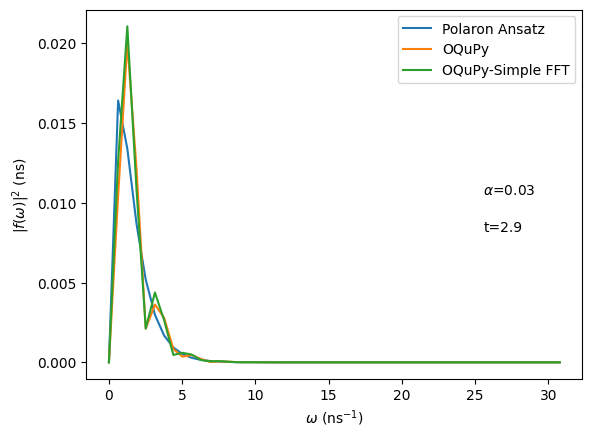

In [22]:
plotdispl2(3.0,200)

100
0.030417809669924745


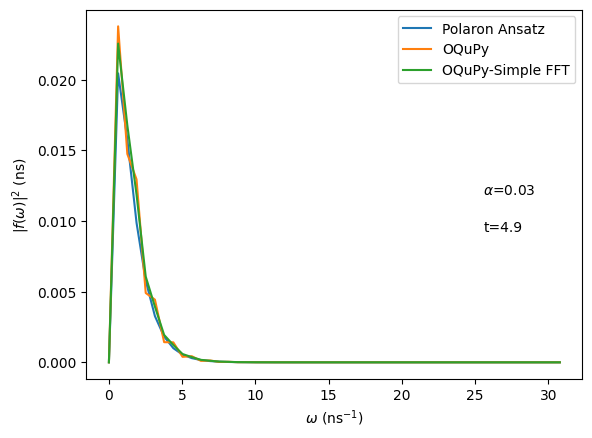

In [23]:
plotdispl2(5.0,200)

100
0.09085673733149272


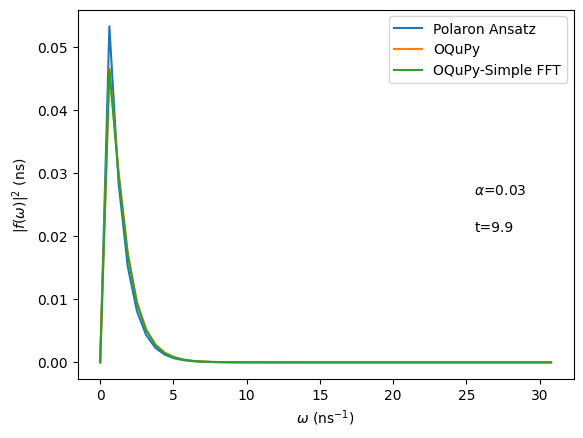

In [24]:
plotdispl2(10.0,200)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --- Preprocess correlations ---
cfarr = np.array(bath_corr._system_correlations)
cfarr[np.isnan(cfarr)] = 0
dt = pt.dt

# --- Main plotting function ---
def plot_grid(time, natten):
    tindx = int(time // dt)

    # =======================
    # Displacement calculation
    # =======================
    n = cfarr.shape[0]
    tdat = cfarr[:(tindx + 1), tindx]

    attenfactor = np.exp(np.arange(-tindx, 1) / natten)
    tdat = tdat * attenfactor

    allomega, ftcfarr, ftcarrdumb = trapezoidal_fft_integral(
        tdat, 0, dt, n
    )

    omega = allomega[:n // 2]

    disps = -2.0j * ftcfarr[:n // 2] * corr.spectral_density(omega)
    dispsdumb = -2.0j * np.exp(-1.0j * tindx * dt) * (
        ftcarrdumb[:n // 2] * corr.spectral_density(omega)
    )

    wq = -2 * h_t(time)

    # =======================
    # Figure layout
    # =======================
    fig = plt.figure(figsize=(10, 5))
    gs = GridSpec(2, 2, width_ratios=[1, 1.2], hspace=0.3, wspace=0.3)

    ax_hx   = fig.add_subplot(gs[0, 0])
    ax_sx   = fig.add_subplot(gs[1, 0])
    ax_disp = fig.add_subplot(gs[:, 1])  # span both rows

    # =======================
    # Column 1, Row 1: h_x(t)
    # =======================
    tgrid = np.arange(len(h_t(t))) * dt
    ax_hx.plot(tgrid, h_t(t))
    ax_hx.set_ylabel(r"$h_x(t)$")
    ax_hx.set_xticks([])
    ax_hx.set_title("Control")

    # =======================
    # Column 1, Row 2: <sigma_x(t)>
    # =======================
    ax_sx.plot(tgrid, sx_t)
    ax_sx.set_xlabel(r"$t$ (ns)")
    ax_sx.set_ylabel(r"$\langle \sigma_x(t) \rangle$")
    ax_sx.set_title("System response")

    # =======================
    # Column 2: Displacements (final time)
    # =======================
    ax_disp.plot(
        omega,
        corr.spectral_density(omega) / (2 * (wq + omega+0.000001)),
        label="Polaron ansatz",
        lw=2,
    )
    ax_disp.plot(
        omega,
        np.abs(disps),
        label="TEMPO",
    )

    ax_disp.set_xlabel(r"$\omega$ (ns$^{-1}$)")
    ax_disp.set_ylabel(r"$|f(\omega)|^2$ (ns)")
    ax_disp.legend()
    ax_disp.set_title("Bath displacements at final time")

    ax_disp.text(
        0.65, 0.9,
        rf"$\alpha = 0.03$\n$t = {tindx * dt:.1f}$",
        transform=ax_disp.transAxes,
    )

    plt.show()

    print("Max |Δ| =", np.max(np.abs(disps - dispsdumb)))


100


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


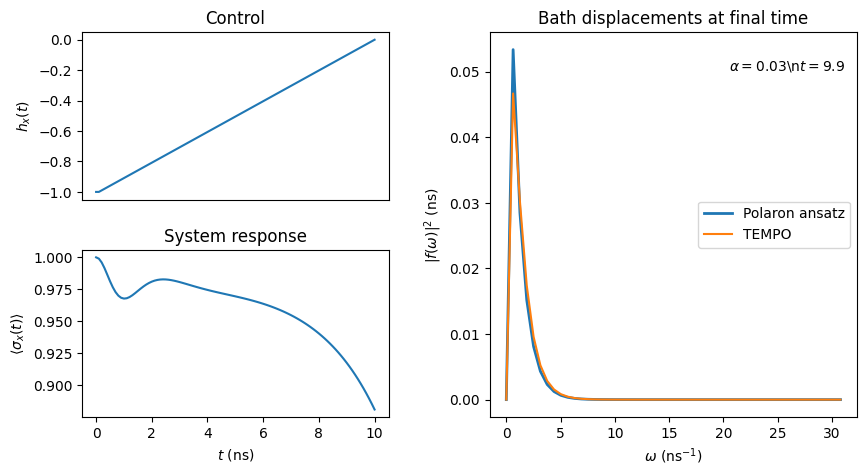

Max |Δ| = 0.09085673733149272


In [28]:
plot_grid(10,200)

In [96]:
import matplotlib as mpl

mpl.rcParams.update({
    # LaTeX rendering (Beamer / PRL)
    "text.usetex": True,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 13,

    # Axis labels & titles
    "axes.labelsize": 16,
    "axes.titlesize": 14,
    "legend.fontsize": 10,

    # Axes & ticks
    "axes.linewidth": 1.4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # No grids
    "axes.grid": False,

    # Output
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

mpl.rcParams["text.latex.preamble"] = r"\usepackage{lmodern}"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

cfarr = np.array(bath_corr._system_correlations)
cfarr[np.isnan(cfarr)] = 0
dt = pt.dt


def plot_grid_prl_style(time, natten):
    tindx = int(time // dt)

    # ===== Displacement calculation =====
    n = cfarr.shape[0]
    tdat = cfarr[:(tindx + 1), tindx]

    attenfactor = np.exp(np.arange(-tindx, 1) / natten)
    tdat *= attenfactor

    allomega, ftcfarr, ftcarrdumb = trapezoidal_fft_integral(
        tdat, 0, dt, n
    )

    omega = allomega[:n // 2]
    Sd = corr.spectral_density(omega)

    disps = -2.0j * ftcfarr[:n // 2] * Sd
    dispsdumb = -2.0j * np.exp(-1.0j * tindx * dt) * (
        ftcarrdumb[:n // 2] * Sd
    )

    wq = -2 * h_t(time)

    fig = plt.figure(figsize=(9.5, 5.2))
    gs = GridSpec(
        2, 2,
        width_ratios=[1.0, 1.25],
        hspace=0.15,
        wspace=0.30,
    )

    ax_hx   = fig.add_subplot(gs[0, 0])
    ax_sx   = fig.add_subplot(gs[1, 0], sharex=ax_hx)
    ax_disp = fig.add_subplot(gs[:, 1])

    tgrid = np.arange(len(h_t(t))) * dt
    ax_hx.plot(tgrid, h_t(t), lw=2,color="black")

    ax_hx.set_ylabel(r"$h_x(t)$")
    ax_hx.set_title(r"Control", pad=6)
    ax_hx.tick_params(labelbottom=False)


    ax_sx.plot(tgrid, sx_t, lw=2,color="black")
    ax_sx.set_xlabel(r"$t$ (ps)")
    ax_sx.set_ylabel(r"$\langle \sigma_x(t) \rangle$")


    ax_disp.plot(
        omega,
        np.abs(disps),
        lw=2,
        label=r"TEMPO",
        color="black"
    )
    ax_disp.plot(
        omega,
        Sd / (2 * (wq + omega)),
        lw=2.2,
        label=r"Polaron ansatz",
        color="red",
        linestyle="dashed"
    )

    ax_hx.set_yticks([0,-0.5,-1])
    ax_hx.set_yticklabels([r"$0$", r"$-\omega_c/2$",r"$ - \omega_c$"])


    ax_disp.set_xlabel(r"$\omega$ (ps$^{-1}$)")
    ax_disp.set_ylabel(r"$|f(\omega)|^2$ (ps)")
    ax_disp.set_title(r"Bath displacements at $t=10ps$", pad=6)

    ax_disp.legend(
        frameon=False,
        loc="upper right",
        handlelength=2.8,
    )
    fig.suptitle(r"$T=0.131 \quad \alpha=0.1$")
    plt.savefig("polaron_control_1K_0.1.pdf")
    plt.show()
    

    print("Max |Δ| =", np.max(np.abs(disps - dispsdumb)))


 14.0%   14 of  100 [#####-----------------------------------] 03:34:43

100
 14.0%   14 of  100 [#####-----------------------------------] 03:34:44

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


 14.0%   14 of  100 [#####-----------------------------------] 03:34:47

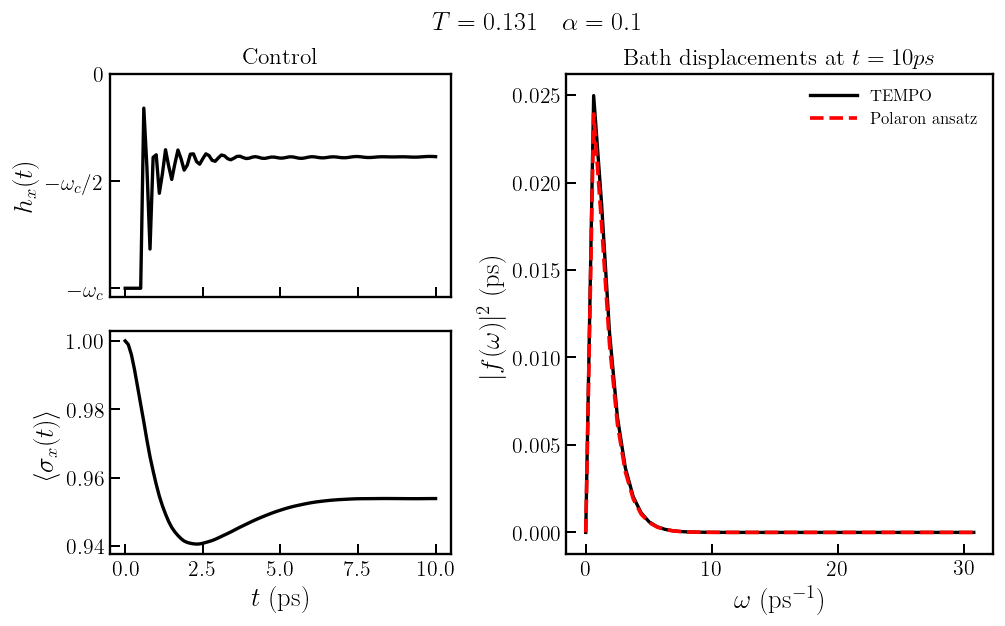

Max |Δ| = 0.04964198170553189


 14.0%   14 of  100 [#####-----------------------------------] 06:01:17

In [ ]:
plot_grid_prl_style(10.0, 200 )